## Project Overview

This project analyzes short-form social media video performance to understand which creative choices and early engagement signals are most associated with high-performing content. The analysis progresses from exploratory data analysis to feature engineering and machine learning, with the goal of modeling both creator-side decisions and platform-side amplification behavior.


In [1]:
%pip install pandas numpy matplotlib seaborn
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

Defaulting to user installation because normal site-packages is not writeable


Note: you may need to restart the kernel to use updated packages.


### Phase 1: Data Validation & Baseline EDA

Purpose: Validate data quality and understand baseline distributions before modeling.


In [2]:
# Ensure pandas is available even if the imports cell hasn't been run yet
try:
	pd
except NameError:
	import pandas as pd

df = pd.read_csv("../data/raw/viral_shorts_reels_performance_dataset.csv")
df.head()

,video_id,duration_sec,hook_strength_score,niche,views_first_hour,views_total,retention_rate,first_3_sec_engagement,music_type,upload_time
0,vid_1,16,0.61,Motivation,10695,886048,0.85,0.26,Viral Track,2024-02-09
1,vid_2,19,0.34,Tech,1812,198243,0.56,0.80,Trending,2024-04-17
2,vid_3,13,0.47,Travel,23247,584171,0.14,0.27,Trending,2024-01-01
3,vid_4,36,0.21,Travel,11515,491291,0.29,0.81,Remix,2024-04-01
4,vid_5,8,0.75,Gaming,13474,607425,0.27,0.44,Viral Track,2024-01-15


In [3]:
df.shape
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 10 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   video_id                400 non-null    object 
 1   duration_sec            400 non-null    int64  
 2   hook_strength_score     400 non-null    float64
 3   niche                   400 non-null    object 
 4   views_first_hour        400 non-null    int64  
 5   views_total             400 non-null    int64  
 6   retention_rate          400 non-null    float64
 7   first_3_sec_engagement  400 non-null    float64
 8   music_type              400 non-null    object 
 9   upload_time             400 non-null    object 
dtypes: float64(3), int64(3), object(4)
memory usage: 31.4+ KB


In [4]:
df.isna().sum()

video_id                  0
duration_sec              0
hook_strength_score       0
niche                     0
views_first_hour          0
views_total               0
retention_rate            0
first_3_sec_engagement    0
music_type                0
upload_time               0
dtype: int64

In [5]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
duration_sec,400.0,25.085000,11.649552,5.0,15.00,26.000,35.00,44.00
hook_strength_score,400.0,0.584850,0.229429,0.2,0.39,0.590,0.77,1.00
views_first_hour,400.0,24730.510000,14180.992070,84.0,12497.00,24984.000,36222.25,49812.00
views_total,400.0,486338.497500,291672.505188,1924.0,227904.50,473516.000,745058.75,992963.00
retention_rate,400.0,0.528275,0.245214,0.1,0.31,0.530,0.74,0.95
first_3_sec_engagement,400.0,0.617800,0.230906,0.2,0.42,0.635,0.82,0.99


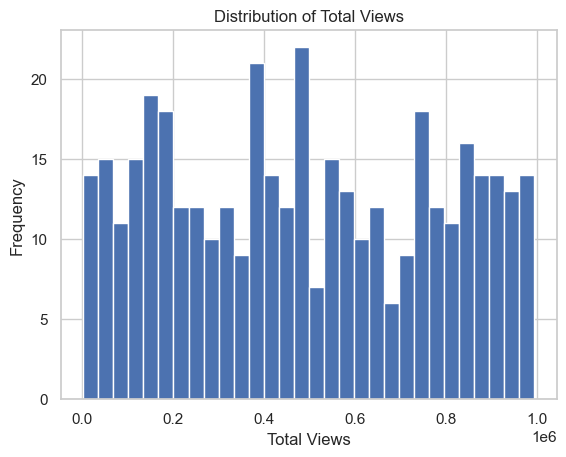

In [6]:
plt.figure()
plt.hist(df["views_total"], bins=30)
plt.title("Distribution of Total Views")
plt.xlabel("Total Views")
plt.ylabel("Frequency")
plt.show()

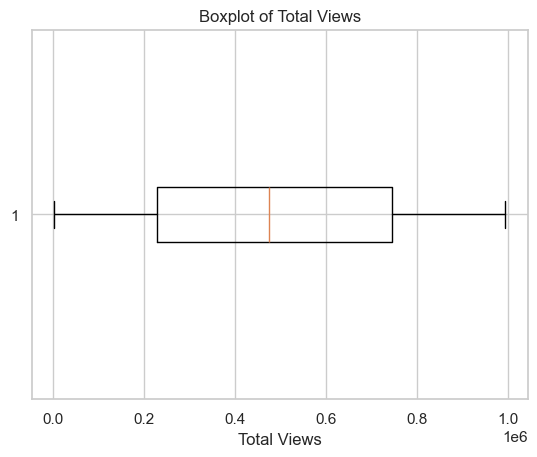

In [7]:
plt.figure()
plt.boxplot(df["views_total"], vert=False)
plt.title("Boxplot of Total Views")
plt.xlabel("Total Views")
plt.show()

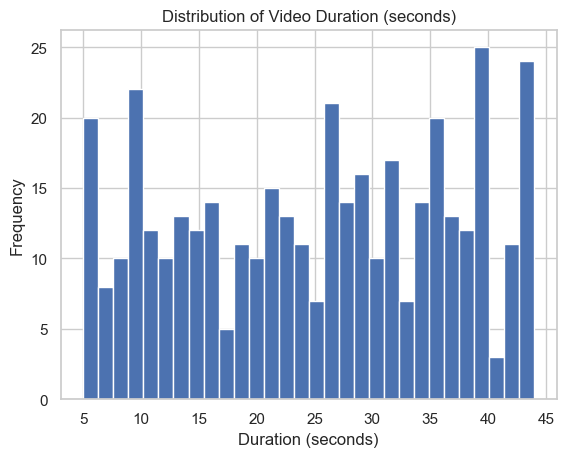

In [8]:
plt.figure()
plt.hist(df["duration_sec"], bins=30)
plt.title("Distribution of Video Duration (seconds)")
plt.xlabel("Duration (seconds)")
plt.ylabel("Frequency")
plt.show()

### Key Takeaways
- Dataset is complete (400 rows, no missing values).
- Total views are highly skewed → averages are misleading.
- Supports focusing on relative performance and early signals.


## Phase 2: Early Engagement vs Final Performance

**Goal:**  
Evaluate whether early engagement signals are associated with long-term content performance.

Due to the highly skewed nature of content performance data, log transformations were applied to total views to improve interpretability.

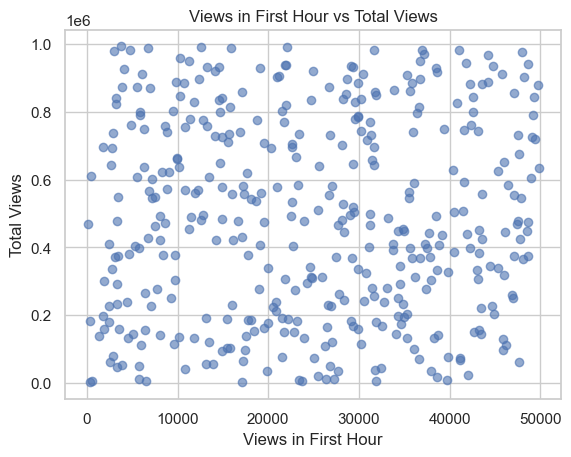

In [9]:
plt.figure()
plt.scatter(df["views_first_hour"], df["views_total"], alpha=0.6)
plt.title("Views in First Hour vs Total Views")
plt.xlabel("Views in First Hour")
plt.ylabel("Total Views")
plt.show()

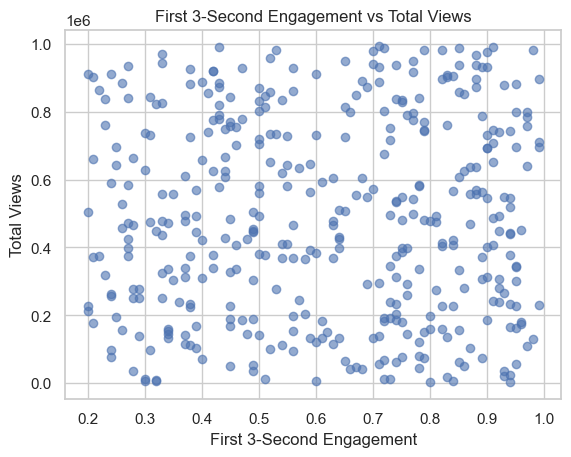

In [10]:
plt.figure()
plt.scatter(df["first_3_sec_engagement"], df["views_total"], alpha=0.6)
plt.title("First 3-Second Engagement vs Total Views")
plt.xlabel("First 3-Second Engagement")
plt.ylabel("Total Views")
plt.show()

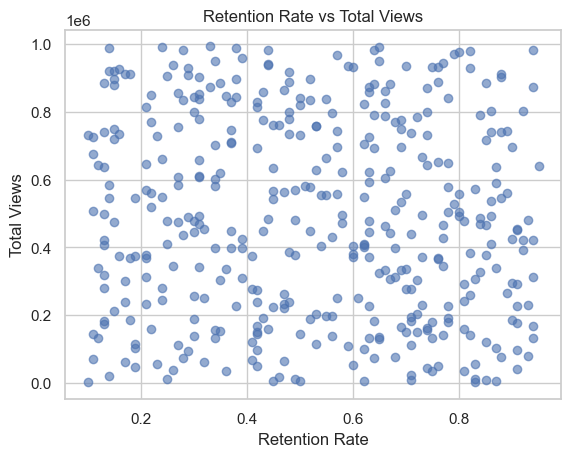

In [11]:
plt.figure()
plt.scatter(df["retention_rate"], df["views_total"], alpha=0.6)
plt.title("Retention Rate vs Total Views")
plt.xlabel("Retention Rate")
plt.ylabel("Total Views")
plt.show()

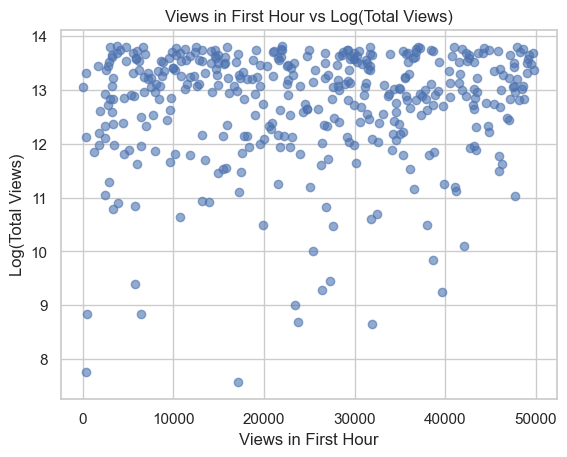

In [12]:
plt.figure()
plt.scatter(df["views_first_hour"], np.log1p(df["views_total"]), alpha=0.6)
plt.title("Views in First Hour vs Log(Total Views)")
plt.xlabel("Views in First Hour")
plt.ylabel("Log(Total Views)")
plt.show()

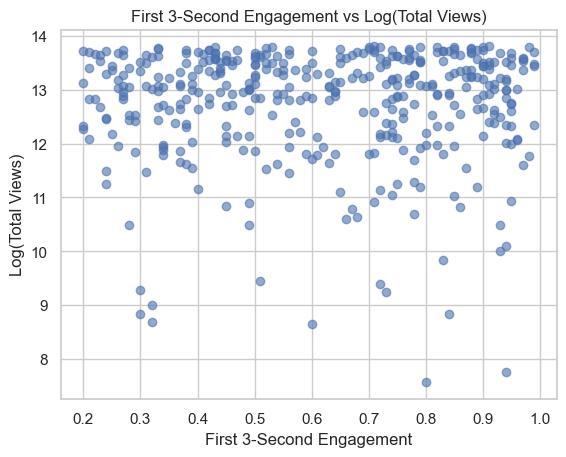

In [13]:
plt.figure()
plt.scatter(
    df["first_3_sec_engagement"],
    np.log1p(df["views_total"]),
    alpha=0.6
)
plt.title("First 3-Second Engagement vs Log(Total Views)")
plt.xlabel("First 3-Second Engagement")
plt.ylabel("Log(Total Views)")
plt.show()

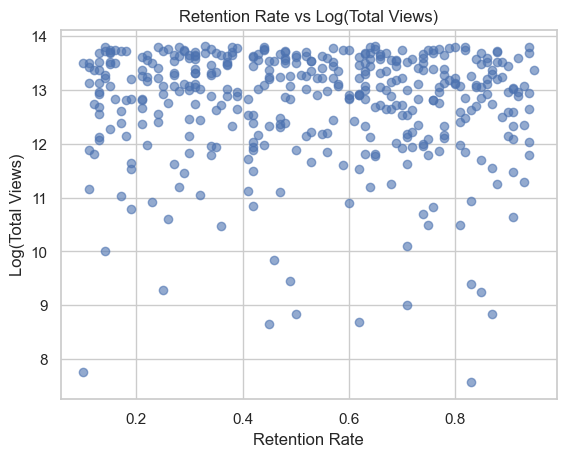

In [14]:
plt.figure()
plt.scatter(
    df["retention_rate"],
    np.log1p(df["views_total"]),
    alpha=0.6
)
plt.title("Retention Rate vs Log(Total Views)")
plt.xlabel("Retention Rate")
plt.ylabel("Log(Total Views)")
plt.show()

### Phase 2 Insights

- Videos with higher first-hour views tend to achieve higher total views, suggesting early momentum plays an important role in long-term performance.
- First 3-second engagement appears to act as a gatekeeping metric; videos with low early engagement rarely become top performers.
- Retention rate shows a consistent positive relationship with total views, indicating that sustained viewer interest contributes to broader reach.
- Log-transforming total views reduces the influence of extreme outliers and reveals clearer relationships between early engagement signals and performance.
- While no single metric guarantees success, early engagement signals collectively differentiate low- and high-performing content.

### Phase 3: Creative Choices and Content Attributes

This phase evaluates creative decisions that creators directly control, including hook strength, video duration, content niche, and music choice. The objective is to assess whether these attributes influence performance independently or primarily shape a video’s potential ceiling.


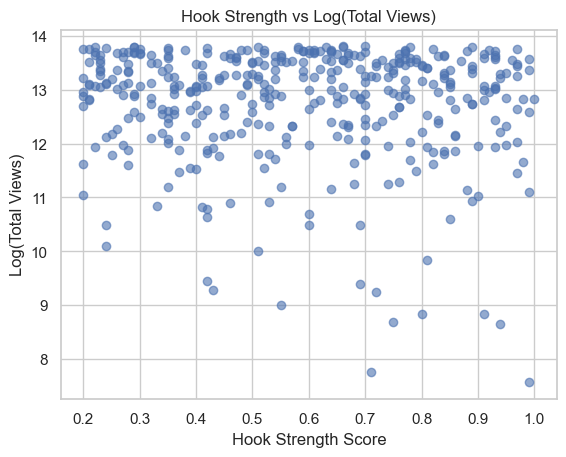

In [15]:
plt.figure()
plt.scatter(
    df["hook_strength_score"],
    np.log1p(df["views_total"]),
    alpha=0.6
)
plt.title("Hook Strength vs Log(Total Views)")
plt.xlabel("Hook Strength Score")
plt.ylabel("Log(Total Views)")
plt.show()

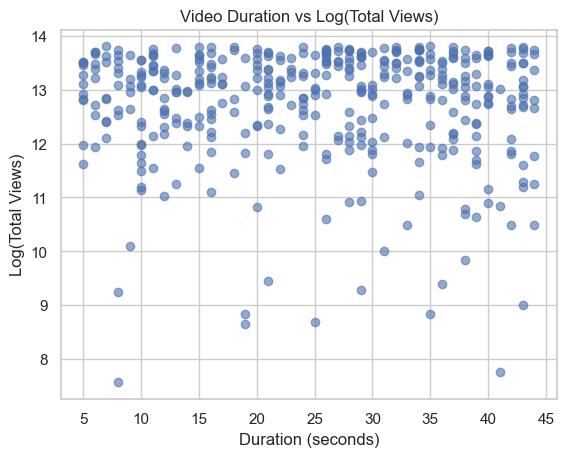

In [16]:
plt.figure()
plt.scatter(
    df["duration_sec"],
    np.log1p(df["views_total"]),
    alpha=0.6
)
plt.title("Video Duration vs Log(Total Views)")
plt.xlabel("Duration (seconds)")
plt.ylabel("Log(Total Views)")
plt.show()

<Figure size 640x480 with 0 Axes>

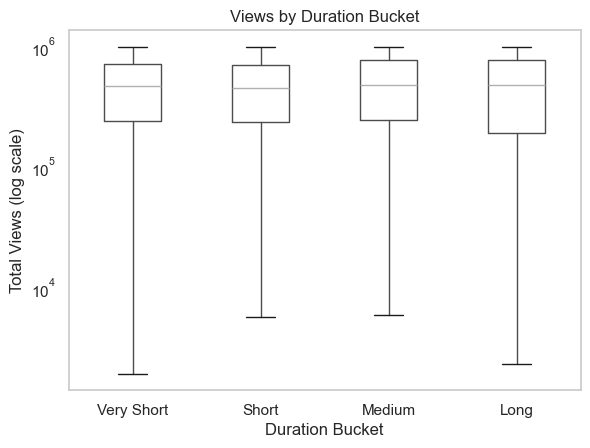

In [17]:
df["duration_bucket"] = pd.cut(
    df["duration_sec"],
    bins=[0, 10, 20, 30, 60],
    labels=["Very Short", "Short", "Medium", "Long"]
)

plt.figure()
df.boxplot(
    column="views_total",
    by="duration_bucket",
    grid=False
)
plt.yscale("log")
plt.title("Views by Duration Bucket")
plt.suptitle("")
plt.xlabel("Duration Bucket")
plt.ylabel("Total Views (log scale)")
plt.show()

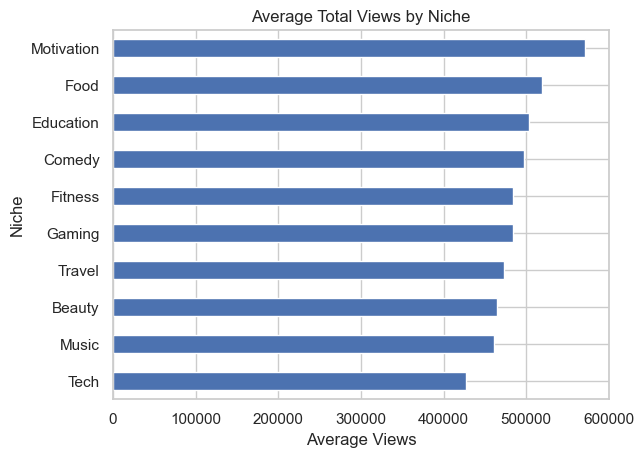

In [18]:
plt.figure()
df.groupby("niche")["views_total"].mean().sort_values().plot(kind="barh")
plt.title("Average Total Views by Niche")
plt.xlabel("Average Views")
plt.ylabel("Niche")
plt.show()

<Figure size 640x480 with 0 Axes>

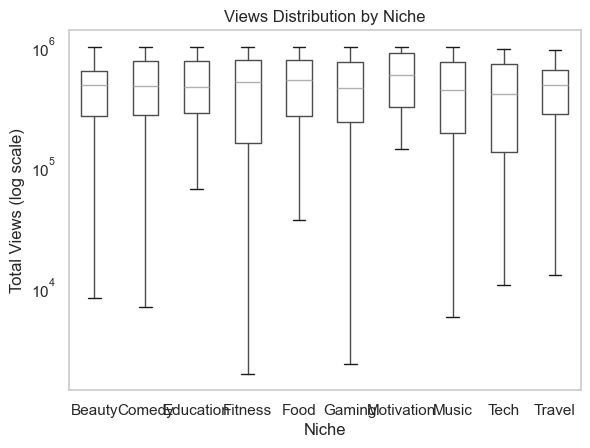

In [19]:
plt.figure()
df.boxplot(column="views_total", by="niche", grid=False)
plt.yscale("log")
plt.title("Views Distribution by Niche")
plt.suptitle("")
plt.xlabel("Niche")
plt.ylabel("Total Views (log scale)")
plt.show()

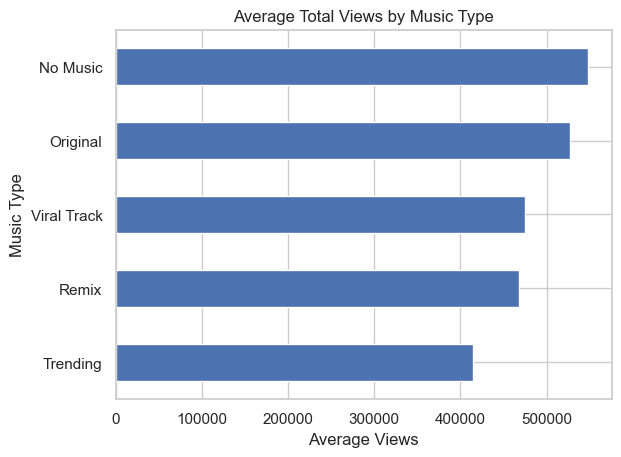

In [20]:
plt.figure()
df.groupby("music_type")["views_total"].mean().sort_values().plot(kind="barh")
plt.title("Average Total Views by Music Type")
plt.xlabel("Average Views")
plt.ylabel("Music Type")
plt.show()

<Figure size 640x480 with 0 Axes>

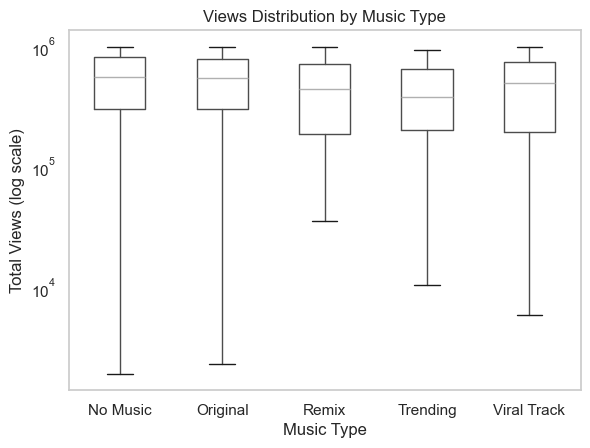

In [21]:
plt.figure()
df.boxplot(column="views_total", by="music_type", grid=False)
plt.yscale("log")
plt.title("Views Distribution by Music Type")
plt.suptitle("")
plt.xlabel("Music Type")
plt.ylabel("Total Views (log scale)")
plt.show()

### Phase 3 Insights

- Higher hook strength scores are associated with higher potential performance, particularly among top-performing videos.
- Video duration alone shows a weak relationship with total views, suggesting content quality outweighs length.
- Performance varies across niches, indicating topic selection influences reach, though variability remains high within categories.
- Music choice shows modest differences in performance and appears less influential than engagement quality.
- Overall, creative decisions shape performance ceilings but do not independently determine success.

### Phase 4: Timing Effects and Feature Engineering

This phase explores whether upload timing influences performance and introduces engineered features for downstream modeling. Date-based features are created for interpretability, while a simplified weekend vs weekday indicator is retained for modeling to reduce noise and dimensionality.




In [22]:
# Ensure datetime
df["upload_time"] = pd.to_datetime(df["upload_time"])

# Define upload_date explicitly
df["upload_date"] = df["upload_time"]

# Day-based features
df["upload_dayofweek"] = df["upload_date"].dt.dayofweek
df["upload_weekday"] = df["upload_date"].dt.day_name()

# Weekend indicator
df["is_weekend"] = df["upload_dayofweek"] >= 5

df.head()

,video_id,duration_sec,hook_strength_score,niche,views_first_hour,views_total,retention_rate,first_3_sec_engagement,music_type,upload_time,duration_bucket,upload_date,upload_dayofweek,upload_weekday,is_weekend
0,vid_1,16,0.61,Motivation,10695,886048,0.85,0.26,Viral Track,2024-02-09,Short,2024-02-09,4,Friday,False
1,vid_2,19,0.34,Tech,1812,198243,0.56,0.80,Trending,2024-04-17,Short,2024-04-17,2,Wednesday,False
2,vid_3,13,0.47,Travel,23247,584171,0.14,0.27,Trending,2024-01-01,Short,2024-01-01,0,Monday,False
3,vid_4,36,0.21,Travel,11515,491291,0.29,0.81,Remix,2024-04-01,Long,2024-04-01,0,Monday,False
4,vid_5,8,0.75,Gaming,13474,607425,0.27,0.44,Viral Track,2024-01-15,Very Short,2024-01-15,0,Monday,False


Note: upload_weekday is used for exploratory analysis and interpretability. 
For modeling and synthesis, timing is represented using a simplified weekend vs weekday indicator.

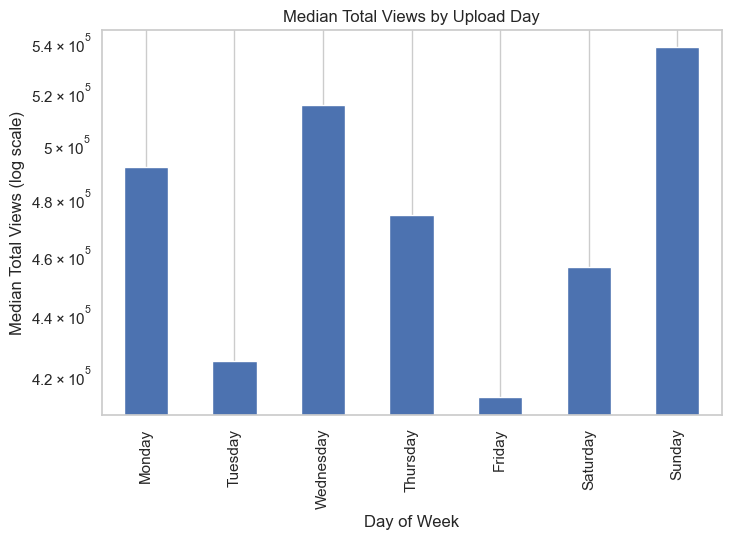

In [23]:
plt.figure(figsize=(8,5))

df.groupby("upload_weekday")["views_total"].median().reindex(
    ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
).plot(kind="bar")

plt.yscale("log")
plt.title("Median Total Views by Upload Day")
plt.xlabel("Day of Week")
plt.ylabel("Median Total Views (log scale)")
plt.show()

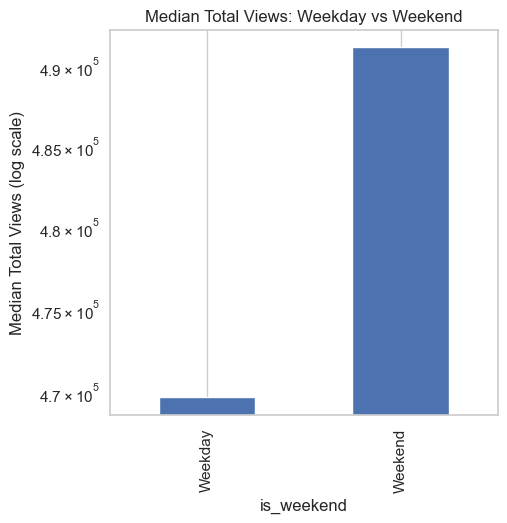

In [24]:
plt.figure(figsize=(5,5))

df.groupby("is_weekend")["views_total"].median().plot(kind="bar")

plt.yscale("log")
plt.xticks([0, 1], ["Weekday", "Weekend"])
plt.title("Median Total Views: Weekday vs Weekend")
plt.ylabel("Median Total Views (log scale)")
plt.show()

### Phase 4 Insights

- Median performance varies modestly across upload days, indicating that posting date may influence exposure but does not dominate outcomes.
- Comparing median views reduces the influence of viral outliers and highlights typical performance patterns.
- Weekend uploads show slightly different median performance than weekdays, though the effect appears limited.
- Overall, timing at the date level acts as a secondary factor compared to early engagement and creative quality.


### Phase 5: Correlation Analysis

This phase assesses linear relationships between numeric features and total views. The goal is not to identify causation, but to evaluate whether simple linear associations exist before transitioning to machine learning models.


In [25]:
numeric_cols = [
    "duration_sec",
    "hook_strength_score",
    "views_first_hour",
    "first_3_sec_engagement",
    "retention_rate",
    "views_total"
]

corr_df = df[numeric_cols]
corr_matrix = corr_df.corr()
corr_matrix



,duration_sec,hook_strength_score,views_first_hour,first_3_sec_engagement,retention_rate,views_total
duration_sec,1.000000,0.036669,0.107365,-0.006406,0.014905,-0.003928
hook_strength_score,0.036669,1.000000,-0.005114,-0.092789,-0.022214,-0.037502
views_first_hour,0.107365,-0.005114,1.000000,0.027599,0.021453,0.035150
first_3_sec_engagement,-0.006406,-0.092789,0.027599,1.000000,0.076217,0.018191
retention_rate,0.014905,-0.022214,0.021453,0.076217,1.000000,-0.083496
views_total,-0.003928,-0.037502,0.035150,0.018191,-0.083496,1.000000


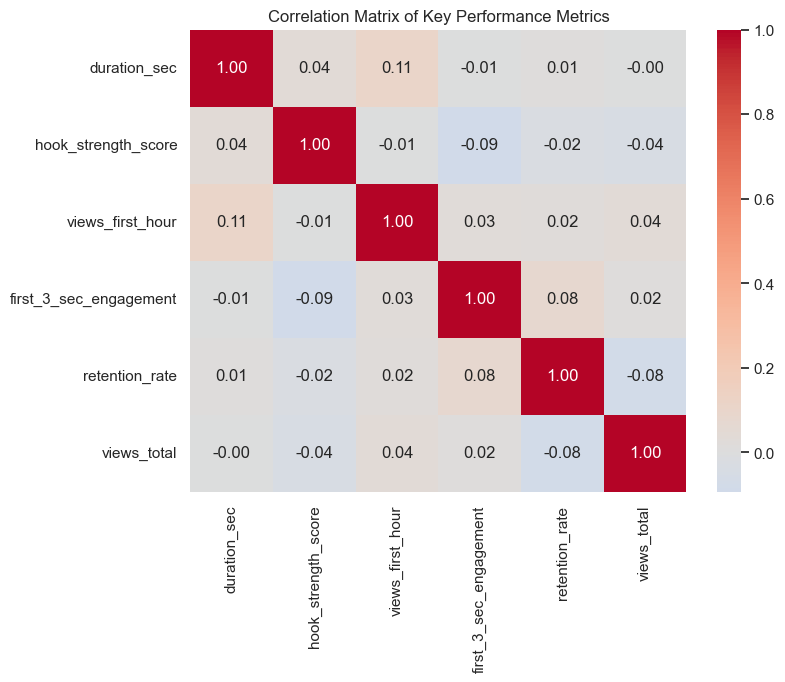

In [26]:
plt.figure(figsize=(8,6))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Matrix of Key Performance Metrics")
plt.show()


### Phase 5 Insights

- No single numeric feature shows a strong linear correlation with total views, highlighting the complexity of social media performance.
- Early engagement and retention metrics exhibit weak individual correlations, suggesting performance is driven by interactions rather than isolated signals.
- Duration and hook strength alone do not explain outcomes, reinforcing earlier findings that creative choices influence performance indirectly.
- These results indicate that non-linear relationships and feature interactions are likely important, motivating the transition to machine learning.


## Modeling Approach and Prediction Frames

This project considers two valid prediction frames:

1. **Early-lifecycle prediction (platform-side):**
   Given early engagement signals shortly after publication, can we predict whether a video will become a top performer?

2. **Pre-upload prediction (creator-side):**
   Before a video is posted, can creative and contextual attributes estimate performance potential?

The initial modeling approach focuses on early-lifecycle prediction, reflecting how platforms evaluate and amplify content after initial viewer interactions.


### Phase 6 – ML Framing

### Early-Lifecycle Prediction Context

Predicting top-performing content shortly after upload is challenging because platform amplification is still unfolding. Early engagement metrics provide partial but informative signals rather than definitive outcomes.

### Goal
Frame content performance as a prediction problem suitable for machine learning.

This modeling phase is exploratory, intended to identify signal presence rather than maximize predictive accuracy.


Based on weak linear relationships, performance is modeled as a classification task focused on identifying top-performing videos.


In [27]:
# Define a performance threshold
threshold = df["views_total"].quantile(0.80)

# Create the target variable
df["top_performer"] = (df["views_total"] >= threshold).astype(int)

# ensures approximately 20% of videos are labeled as top performers
df["top_performer"].value_counts(normalize=True)


top_performer
0    0.8
1    0.2
Name: proportion, dtype: float64

In [28]:
# Feature columns (inputs)
feature_cols = [
    "duration_sec",
    "hook_strength_score",
    "first_3_sec_engagement",
    "retention_rate",
    "views_first_hour",
    "is_weekend"
]

# X = input features
X = df[feature_cols]

# y = target variable (what we want to predict)
y = df["top_performer"]


### Phase 7 – Baseline Model
### Goal
Establish a baseline machine learning model to evaluate whether early signals can predict top-performing content.

I'll be using logistic regression to evaluate whether early engagement and creative features show a clear, linear relationship with content performance.


In [29]:
%pip install scikit-learn
from sklearn.model_selection import train_test_split

# split data into train/test sets to evaluate generalization.


X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,      # 25% of data is held out for testing
    random_state=42,     # makes results reproducible
    stratify=y           # keeps the same 80/20 label ratio in train and test
)


Defaulting to user installation because normal site-packages is not writeable


Note: you may need to restart the kernel to use updated packages.


In [30]:
from sklearn.preprocessing import StandardScaler

# Feature scaling
# So features are centered around 0 and have similar spread.

scaler = StandardScaler()

# Fit the scaler on TRAINING data only (important!)
X_train_scaled = scaler.fit_transform(X_train)

# Apply the same scaling to TEST data
X_test_scaled = scaler.transform(X_test)

Numerical warnings indicate instability under linear assumptions, reinforcing the need for non-linear models.


In [31]:
from sklearn.linear_model import LogisticRegression

# Train Logistic Regression model

model = LogisticRegression(random_state=42)

# learn patterns from X_train -> y_train
model.fit(X_train_scaled, y_train)



/Users/bettinageorge/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:165: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/bettinageorge/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:165: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/bettinageorge/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:165: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights + intercept


LogisticRegression(random_state=42)

In [32]:
# Predict on unseen data

y_pred = model.predict(X_test_scaled)


In [33]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)



Accuracy: 0.8


In [34]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))



              precision    recall  f1-score   support

           0       0.80      1.00      0.89        80
           1       0.00      0.00      0.00        20

    accuracy                           0.80       100
   macro avg       0.40      0.50      0.44       100
weighted avg       0.64      0.80      0.71       100



/Users/bettinageorge/Library/Python/3.9/lib/python/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/bettinageorge/Library/Python/3.9/lib/python/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/bettinageorge/Library/Python/3.9/lib/python/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capita

In [35]:
from sklearn.metrics import confusion_matrix

print(confusion_matrix(y_test, y_pred))



[[80  0]
 [20  0]]


### Mid-point Check...the Decision Threshold will be Adjusted

The initial logistic regression model predicted all videos as non-top performers. This happened because the dataset is imbalanced, with far fewer top-performing videos than non-top ones, and the default decision threshold was too strict.

To better understand the model’s behavior, the decision threshold will be lowered so the model would attempt to identify top performers. 

In [36]:
# Get predicted probabilities for class 1 (top performer)
y_prob = model.predict_proba(X_test_scaled)[:, 1]

# Lower threshold = more aggressive predictions
threshold = 0.30

# Convert probabilities to class predictions
y_pred_custom = (y_prob >= threshold).astype(int)

# Evaluate new predictions
print(confusion_matrix(y_test, y_pred_custom))
print(classification_report(y_test, y_pred_custom))


[[75  5]
 [20  0]]
              precision    recall  f1-score   support

           0       0.79      0.94      0.86        80
           1       0.00      0.00      0.00        20

    accuracy                           0.75       100
   macro avg       0.39      0.47      0.43       100
weighted avg       0.63      0.75      0.69       100




The baseline logistic regression model predicts almost all videos as non-top performers. While overall accuracy appears high due to class imbalance, the model fails to identify any top-performing videos. This indicates that simple linear decision boundaries are insufficient for separating high-performing content in this dataset.

### The outcome of lowering the threshhold

Lowering the decision threshold increases model sensitivity, but the model still failed to correctly identify top-performing videos. This suggests that the limitation lies in the model’s linear assumptions rather than the classification threshold itself. Hence:

### Addressing Class Imbalance

Because top performers represent a small fraction of the data, class imbalance adjustments are applied to encourage the model to identify high-performing content.


In [37]:
model_weighted = LogisticRegression(
    random_state=42,
    class_weight="balanced"
)

model_weighted.fit(X_train_scaled, y_train)

y_pred_weighted = model_weighted.predict(X_test_scaled)

print(confusion_matrix(y_test, y_pred_weighted))
print(classification_report(y_test, y_pred_weighted))


[[39 41]
 [12  8]]
              precision    recall  f1-score   support

           0       0.76      0.49      0.60        80
           1       0.16      0.40      0.23        20

    accuracy                           0.47       100
   macro avg       0.46      0.44      0.41       100
weighted avg       0.64      0.47      0.52       100



/Users/bettinageorge/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:165: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/bettinageorge/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:165: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/bettinageorge/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:165: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights + intercept


In [38]:
y_prob = model_weighted.predict_proba(X_test_scaled)[:, 1]
print("Predicted probabilities (first 10):", y_prob[:10])

Predicted probabilities (first 10): [0.52289547 0.47283648 0.58115347 0.54375585 0.57178609 0.45501883
 0.56716479 0.49646924 0.58619547 0.48913419]


### Updated Model Behavior

Imbalance-aware adjustments improve sensitivity to top-performing videos, revealing weak but meaningful predictive signal in early engagement features.




### Phase 8: Tree-Based Model

### Goal
Capture non-linear relationships and feature interactions that linear models could not represent.

In [39]:
from sklearn.tree import DecisionTreeClassifier
# Train a Decision Tree model


# max_depth limits how complex the tree can get. ..preventing overfitting and keeping the model interpretable
tree_model = DecisionTreeClassifier(
    max_depth=4,        # keep it simple on purpose
    random_state=42
)
# learn patterns from X_train -> y_train
tree_model.fit(X_train, y_train)


DecisionTreeClassifier(max_depth=4, random_state=42)

In [40]:
# Predict class labels on test data
y_pred_tree = tree_model.predict(X_test)


In [41]:
from sklearn.metrics import confusion_matrix, classification_report

print(confusion_matrix(y_test, y_pred_tree))


[[80  0]
 [20  0]]


In [42]:
print(classification_report(y_test, y_pred_tree))


              precision    recall  f1-score   support

           0       0.80      1.00      0.89        80
           1       0.00      0.00      0.00        20

    accuracy                           0.80       100
   macro avg       0.40      0.50      0.44       100
weighted avg       0.64      0.80      0.71       100



/Users/bettinageorge/Library/Python/3.9/lib/python/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/bettinageorge/Library/Python/3.9/lib/python/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/bettinageorge/Library/Python/3.9/lib/python/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capita

In [43]:
# Feature importance

importances = pd.Series(
    tree_model.feature_importances_,
    index=feature_cols
).sort_values(ascending=False)

print(importances)


first_3_sec_engagement    0.289646
hook_strength_score       0.279514
retention_rate            0.200907
views_first_hour          0.122712
duration_sec              0.107222
is_weekend                0.000000
dtype: float64


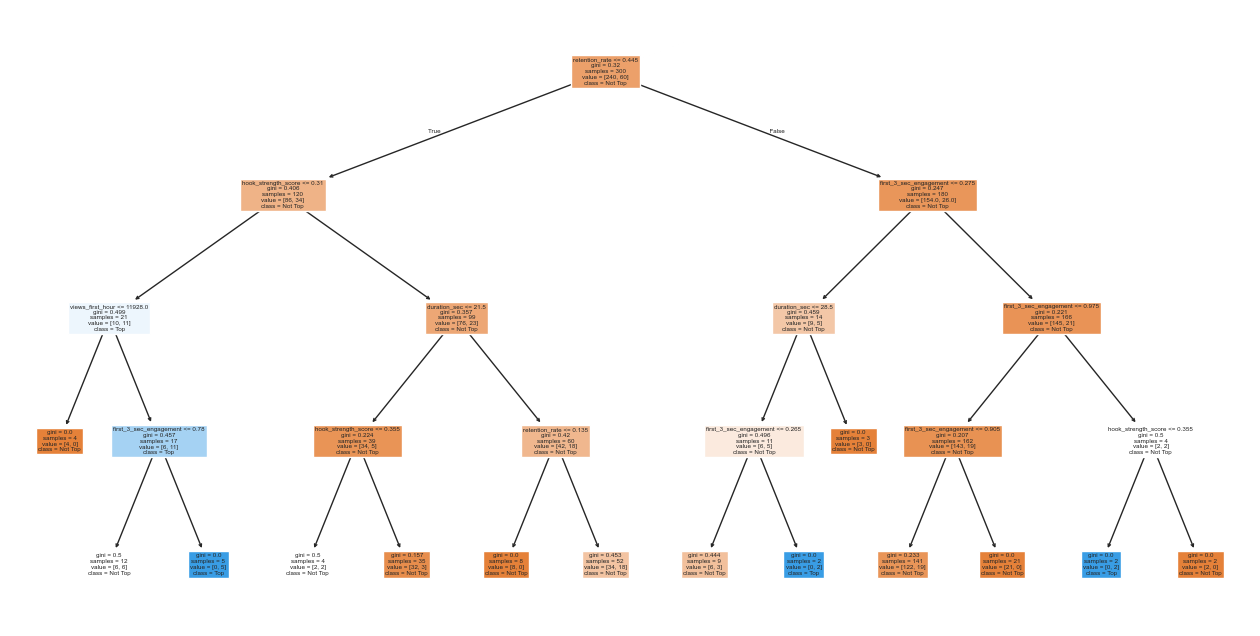

In [44]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(16,8))
plot_tree(
    tree_model,
    feature_names=feature_cols,
    class_names=["Not Top", "Top"],
    filled=True
)
plt.show()


In [45]:
coefficients = pd.Series(
    model.coef_[0],
    index=feature_cols
).sort_values()

coefficients


retention_rate           -0.301446
hook_strength_score      -0.230422
first_3_sec_engagement   -0.129457
is_weekend                0.051315
duration_sec              0.110571
views_first_hour          0.111762
dtype: float64

In [46]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=6,
    class_weight="balanced",
    random_state=42
)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

print(confusion_matrix(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))


[[69 11]
 [18  2]]
              precision    recall  f1-score   support

           0       0.79      0.86      0.83        80
           1       0.15      0.10      0.12        20

    accuracy                           0.71       100
   macro avg       0.47      0.48      0.47       100
weighted avg       0.67      0.71      0.69       100



### Random Forest Outcome

The Random Forest model identifies a small number of top-performing videos, confirming the presence of weak but meaningful signal in early engagement features. While recall remains low, the model performs better than chance and supports ranking-based use cases.


### Tree-Based Model Interpretation

Tree-based models highlight conditional relationships between engagement signals, providing interpretability even when predictive performance remains modest.


### Early-Lifecycle Modeling Summary

Early engagement signals contain limited but meaningful information about performance. Results suggest that content success emerges from interacting signals rather than single dominant factors.


Why performance remains modest:
- Dataset is synthetic/small (400 rows).
- Performance is threshold-based (top 20%), amplifying noise.
- Platform amplification introduces stochastic effects not captured here.



### Early-Lifecycle Prediction Conclusion

Early engagement signals provide limited predictive power for binary classification, but are useful for prioritization and relative performance estimation. These findings motivate a shift toward creator-side, pre-upload prediction where features are more stable and controllable.


## Phase 9: Pre-Upload (Creator-Side) Performance Prediction


### Motivation

Unlike early-lifecycle prediction, pre-upload modeling relies only on features available to creators before posting. This phase evaluates whether creative and contextual decisions can estimate performance potential without engagement feedback.


#### features:
duration_sec
hook_strength_score
niche
music_type
is_weekend


In [47]:
y = df["top_performer"]

In [48]:
# Pre-upload feature selection

pre_upload_features = [
    "duration_sec",
    "hook_strength_score",
    "is_weekend"
]

X_pre = df[pre_upload_features]
y = df["top_performer"]

In [49]:
# One-hot encode categorical variables
X_pre = pd.get_dummies(
    df[["duration_sec", "hook_strength_score", "is_weekend", "niche", "music_type"]],
    drop_first=True
)

In [50]:
from sklearn.model_selection import train_test_split

X_train_pre, X_test_pre, y_train_pre, y_test_pre = train_test_split(
    X_pre,
    y,
    test_size=0.25,
    random_state=42,
    stratify=y
)


In [51]:
from sklearn.linear_model import LogisticRegression

pre_model = LogisticRegression(
    class_weight="balanced",
    random_state=42
)

pre_model.fit(X_train_pre, y_train_pre)

y_pred_pre = pre_model.predict(X_test_pre)


/Users/bettinageorge/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:165: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/bettinageorge/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:165: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/bettinageorge/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:165: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/bettinageorge/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:295: RuntimeWarning: divide by zero encountered in matmul
  grad[:n_features] = X.T @ grad_pointwise + l2_reg_strength * weights
/Users/bettinageorge/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:295: RuntimeWarning: overflow encountered in matmul
  grad[:n_fea

In [52]:
from sklearn.metrics import confusion_matrix, classification_report

print(confusion_matrix(y_test_pre, y_pred_pre))
print(classification_report(y_test_pre, y_pred_pre))


[[31 49]
 [ 8 12]]
              precision    recall  f1-score   support

           0       0.79      0.39      0.52        80
           1       0.20      0.60      0.30        20

    accuracy                           0.43       100
   macro avg       0.50      0.49      0.41       100
weighted avg       0.68      0.43      0.48       100



In [53]:
import joblib

joblib.dump(rf_model, "model.pkl")

['model.pkl']

## Phase 10: Pre-Upload Regression Model

**Goal:** Predict `views_total` using only features available *before* a reel is posted.

**Features used (pre-upload only):**
- `duration_sec`
- `hook_strength_score`
- `niche` (one-hot encoded)
- `music_type` (one-hot encoded)
- `is_weekend` (derived from `upload_time`: 1 = Saturday/Sunday, 0 = weekday)

**Excluded (post-upload metrics):** `views_first_hour`, `retention_rate`, `first_3_sec_engagement`

In [54]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error
import joblib

# Ensure is_weekend is integer (0/1)
df["is_weekend"] = df["is_weekend"].astype(int)

# One-hot encode categorical variables; keep only pre-upload features
X_reg = pd.get_dummies(
    df[["duration_sec", "hook_strength_score", "niche", "music_type", "is_weekend"]],
    columns=["niche", "music_type"]
)

# Target variable
y_reg = df["views_total"]

# Train / test split
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42
)

print("Training samples:", X_train_reg.shape[0])
print("Test samples    :", X_test_reg.shape[0])
print("Features        :", X_reg.columns.tolist())

Training samples: 320
Test samples    : 80
Features        : ['duration_sec', 'hook_strength_score', 'is_weekend', 'niche_Beauty', 'niche_Comedy', 'niche_Education', 'niche_Fitness', 'niche_Food', 'niche_Gaming', 'niche_Motivation', 'niche_Music', 'niche_Tech', 'niche_Travel', 'music_type_No Music', 'music_type_Original', 'music_type_Remix', 'music_type_Trending', 'music_type_Viral Track']


In [55]:
# Train RandomForestRegressor with pre-upload features only
rf_regressor = RandomForestRegressor(
    n_estimators=200,
    max_depth=10,
    random_state=42
)

rf_regressor.fit(X_train_reg, y_train_reg)

# Evaluate on held-out test set
y_pred_reg = rf_regressor.predict(X_test_reg)
mae = mean_absolute_error(y_test_reg, y_pred_reg)
print(f"Mean Absolute Error (MAE): {mae:,.0f} views")

Mean Absolute Error (MAE): 283,198 views


In [56]:
# Save the trained model
joblib.dump(rf_regressor, "model.pkl")
print("Model saved to model.pkl")

# Save the feature column order so the API can align prediction inputs
feature_cols_reg = X_reg.columns.tolist()
joblib.dump(feature_cols_reg, "features.pkl")
print("Features saved to features.pkl")
print("Feature columns:", feature_cols_reg)

Model saved to model.pkl
Features saved to features.pkl
Feature columns: ['duration_sec', 'hook_strength_score', 'is_weekend', 'niche_Beauty', 'niche_Comedy', 'niche_Education', 'niche_Fitness', 'niche_Food', 'niche_Gaming', 'niche_Motivation', 'niche_Music', 'niche_Tech', 'niche_Travel', 'music_type_No Music', 'music_type_Original', 'music_type_Remix', 'music_type_Trending', 'music_type_Viral Track']


In [57]:
# --- Prediction Test ---
# Sample pre-upload reel input
sample = pd.DataFrame([{
    "duration_sec": 12,
    "hook_strength_score": 0.8,
    "niche": "Tech",
    "music_type": "Trending",
    "is_weekend": 1
}])

# One-hot encode and align to training feature columns
sample_encoded = pd.get_dummies(sample, columns=["niche", "music_type"])
sample_encoded = sample_encoded.reindex(columns=feature_cols_reg, fill_value=0)

# Run prediction
predicted_views = rf_regressor.predict(sample_encoded)[0]
print(f"Predicted Total Views: {predicted_views:,.0f}")

Predicted Total Views: 353,003
